In [2]:
# Packages imported into the project environment 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Clean style to make plots more legible
sns.set_style('whitegrid')
sns.set_palette('deep')

In [3]:
#### Loading the NHTS data in csv
nhts_data = pd.read_csv('NHTS(in).csv')

# Displaying Data to check that it was imported correctly
nhts_data 

,household_id,census_division,census_region,driver_count,household_income,household_size,household_workers,home_type,household_location,number_adults_household,...,urban,vehicle_type,hybrid,make,vehicle_age,vehicle_commercial,vehicle_delivery,vehicle_rideshare,fuel_type,vehicle_year
0,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,7,No,NaN,NaN,Gas,2015
1,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,3,No,NaN,NaN,Gas,2019
2,9000013016,New England,Northeast,2,"$75,000 to $99,999",2,2,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Toyota,11,No,NaN,NaN,Gas,2011
3,9000013039,New England,Northeast,2,"$75,000 to $99,999",4,1,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Nissan/Datsun,7,No,NaN,NaN,Gas,2015
4,9000013041,New England,Northeast,1,"$175,000 or more",1,1,"Townhome, Condo",Urban,1,...,In an urban area,Automobile/car/stationwagon,No,BMV,8,No,NaN,NaN,Gas,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14679,9000218013,East South Central,South,1,"$15,000 to $24,999",2,0,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Volkswagen,4,No,NaN,NaN,Gas,2018
14680,9000218021,East South Central,South,1,"$25,000 to $34,999",1,0,One-family detached,Rural,1,...,Not in an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Ford,6,Yes,No,No,Gas,2016
14681,9000218034,East South Central,South,2,"$25,000 to $34,999",2,0,One-family detached,Rural,2,...,Not in an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Honda,4,No,NaN,NaN,Gas,2018
14682,9000218034,East South Central,South,2,"$25,000 to $34,999",2,0,One-family detached,Rural,2,...,Not in an urban area,Pickup Truck,No,Toyota,19,No,NaN,NaN,Gas,2003


In [4]:
#This gives a quick summary of numerical variables
nhts_data.describe()

,household_id,driver_count,household_size,household_workers,number_adults_household,vehicles_per_household,travel_date,vehicle_age,vehicle_year
count,1.468400e+04,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000
mean,9.000113e+09,2.014165,2.558090,1.179447,2.061223,2.534323,202211.722623,10.174271,2011.866658
std,5.936829e+04,0.814926,1.333751,0.984043,0.812286,1.436046,20.578951,7.959353,8.009252
min,9.000013e+09,0.000000,1.000000,0.000000,1.000000,1.000000,202201.000000,1.000000,1982.000000
25%,9.000057e+09,2.000000,2.000000,0.000000,2.000000,2.000000,202204.000000,4.000000,2007.000000
50%,9.000107e+09,2.000000,2.000000,1.000000,2.000000,2.000000,202208.000000,8.000000,2014.000000
75%,9.000166e+09,2.000000,3.000000,2.000000,2.000000,3.000000,202211.000000,15.000000,2018.000000
max,9.000218e+09,7.000000,10.000000,6.000000,8.000000,17.000000,202301.000000,40.000000,2023.000000


In [5]:
# This describes categorical values we are using in this project, for this project, we are using household income and make and model

nhts_data['make'].value_counts()


make
Toyota                                        1974
Ford                                          1921
Chevrolet                                     1571
Honda                                         1507
Nissan/Datsun                                  702
Subaru                                         601
Dodge                                          582
Jeep                                           554
Hyundai                                        516
Other make                                     500
Suppressed for confidential reason             457
GMC                                            447
KIA                                            376
Volkswagen                                     315
Mazda                                          292
Lexus                                          291
BMV                                            290
Buick/Opel                                     239
Mercedes-Benz                                  228
Chrysler                  

In [6]:
# This is in a separate cell so both are displayed
nhts_data['household_income'].value_counts()

household_income
$50,000 to $74,999        2535
$75,000 to $99,999        2242
$175,000 or more          1879
$100,000 to $124,999      1844
$125,000 to $149,999      1394
$35,000 to $49,999        1360
$150,000 to $174,999      1357
$25,000 to $34,999         776
$15,000 to $24,999         578
Less than $10,000          279
$10,000 to $14,999         233
I prefer not to answer     197
I don't know                10
Name: count, dtype: int64

In [7]:
#This checks for missing data values
nhts_data.isnull().sum()

household_id                   0
census_division                0
census_region                  0
driver_count                   0
household_income               0
household_size                 0
household_workers              0
home_type                      0
household_location             0
number_adults_household        0
vehicles_per_household         0
travel_date                    0
travel_day                     0
urban                          0
vehicle_type                   0
hybrid                         0
make                         116
vehicle_age                    0
vehicle_commercial            39
vehicle_delivery           13491
vehicle_rideshare          13487
fuel_type                     32
vehicle_year                   0
dtype: int64

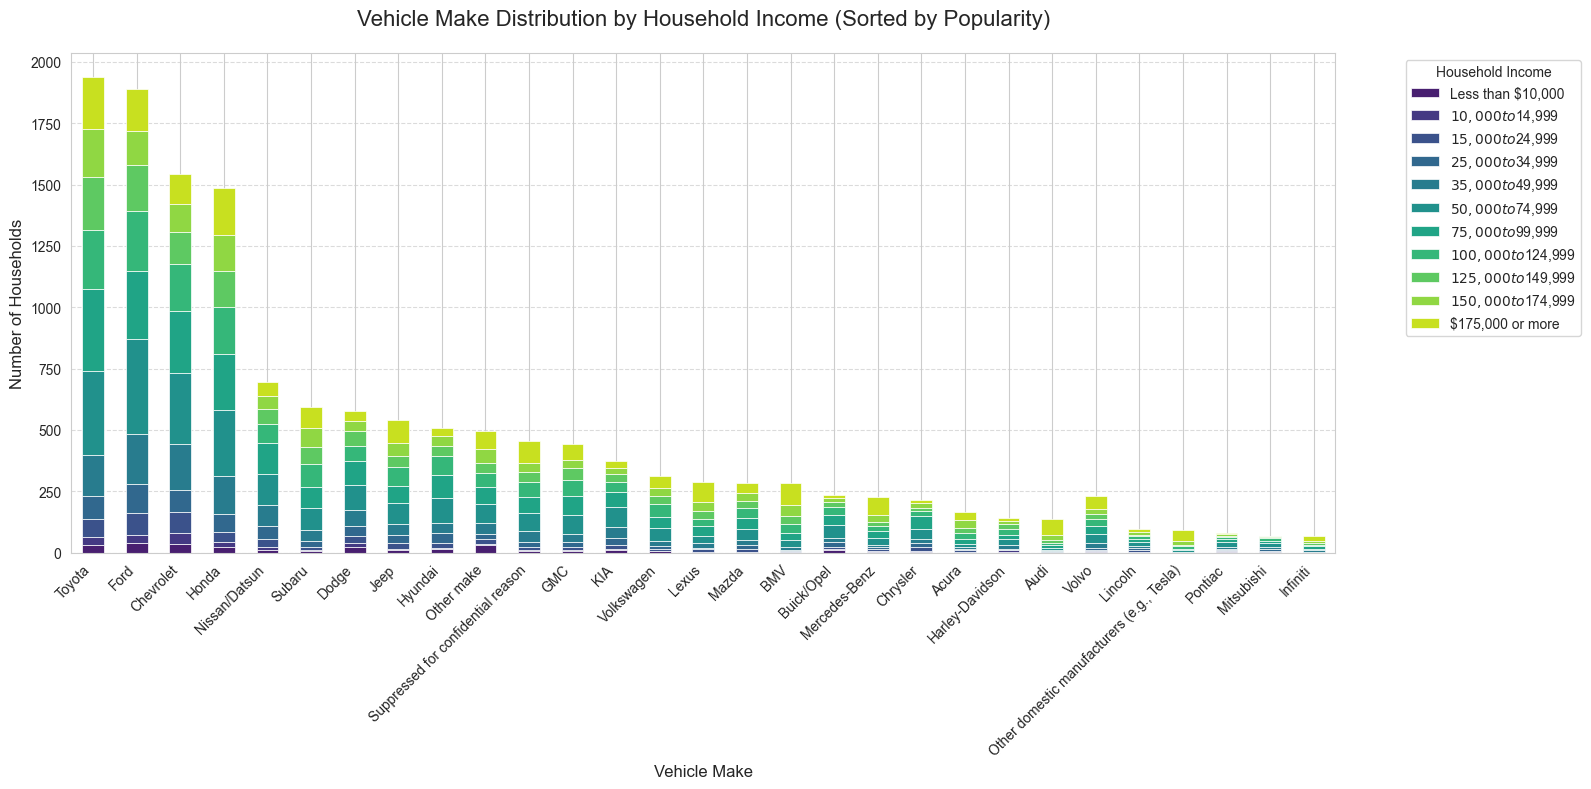

In [8]:
# Define the logical order for income (since strings sort alphabetically by default)
income_order = [
    'Less than $10,000', '$10,000 to $14,999', '$15,000 to $24,999', 
    '$25,000 to $34,999', '$35,000 to $49,999', '$50,000 to $74,999', 
    '$75,000 to $99,999', '$100,000 to $124,999', '$125,000 to $149,999', 
    '$150,000 to $174,999', '$175,000 or more'
]

# Filter out the "I don't know" or missing values to clean data
filtered_data = nhts_data[nhts_data['household_income'].isin(income_order)].copy()
filtered_data['household_income'] = pd.Categorical(filtered_data['household_income'], categories=income_order, ordered=True)

# Group and sort 'Make' by the total number of vehicles (descending)
make_counts = filtered_data['make'].value_counts().index
data_grouped = filtered_data.groupby(['make', 'household_income'], observed=False).size().unstack(fill_value=0)
data_grouped = data_grouped.loc[make_counts] # Reorder rows based on popularity

# Plotting data
plt.figure(figsize=(16, 8))
palette = sns.color_palette("viridis", len(income_order)) # Using a perceptually uniform palette

data_grouped.plot(kind='bar', stacked=True, ax=plt.gca(), color=palette, edgecolor='white', linewidth=0.5)

# Cleaning up chart
plt.title('Vehicle Make Distribution by Household Income (Sorted by Popularity)', fontsize=16, pad=20)
plt.xlabel('Vehicle Make', fontsize=12)
plt.ylabel('Number of Households', fontsize=12)
plt.xticks(rotation=45, ha='right') # Angled labels are easier to read than vertical ones
plt.legend(title='Household Income', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<Figure size 2500x1200 with 0 Axes>

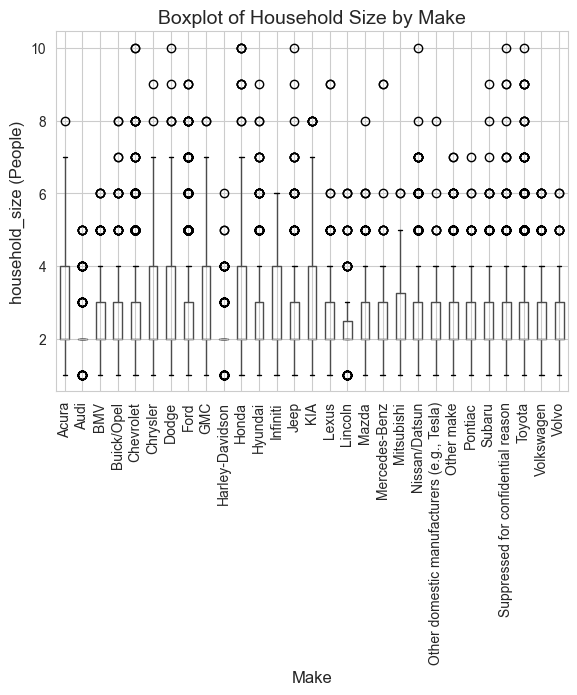

In [9]:
## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (25,12))



## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot = nhts_data.boxplot(column = 'household_size', by = 'make')

## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read
plt.xticks(rotation=90)

### the next two lines create your axis labels
plt.xlabel('Make', fontsize=12)
plt.ylabel('household_size (People)', fontsize=12)
### this line gives your plot a title
plt.title('Boxplot of Household Size by Make', fontsize=14)
plt.suptitle('') #removes the automatic pandas title

## Step 4: tell python to show the plot
plt.show()

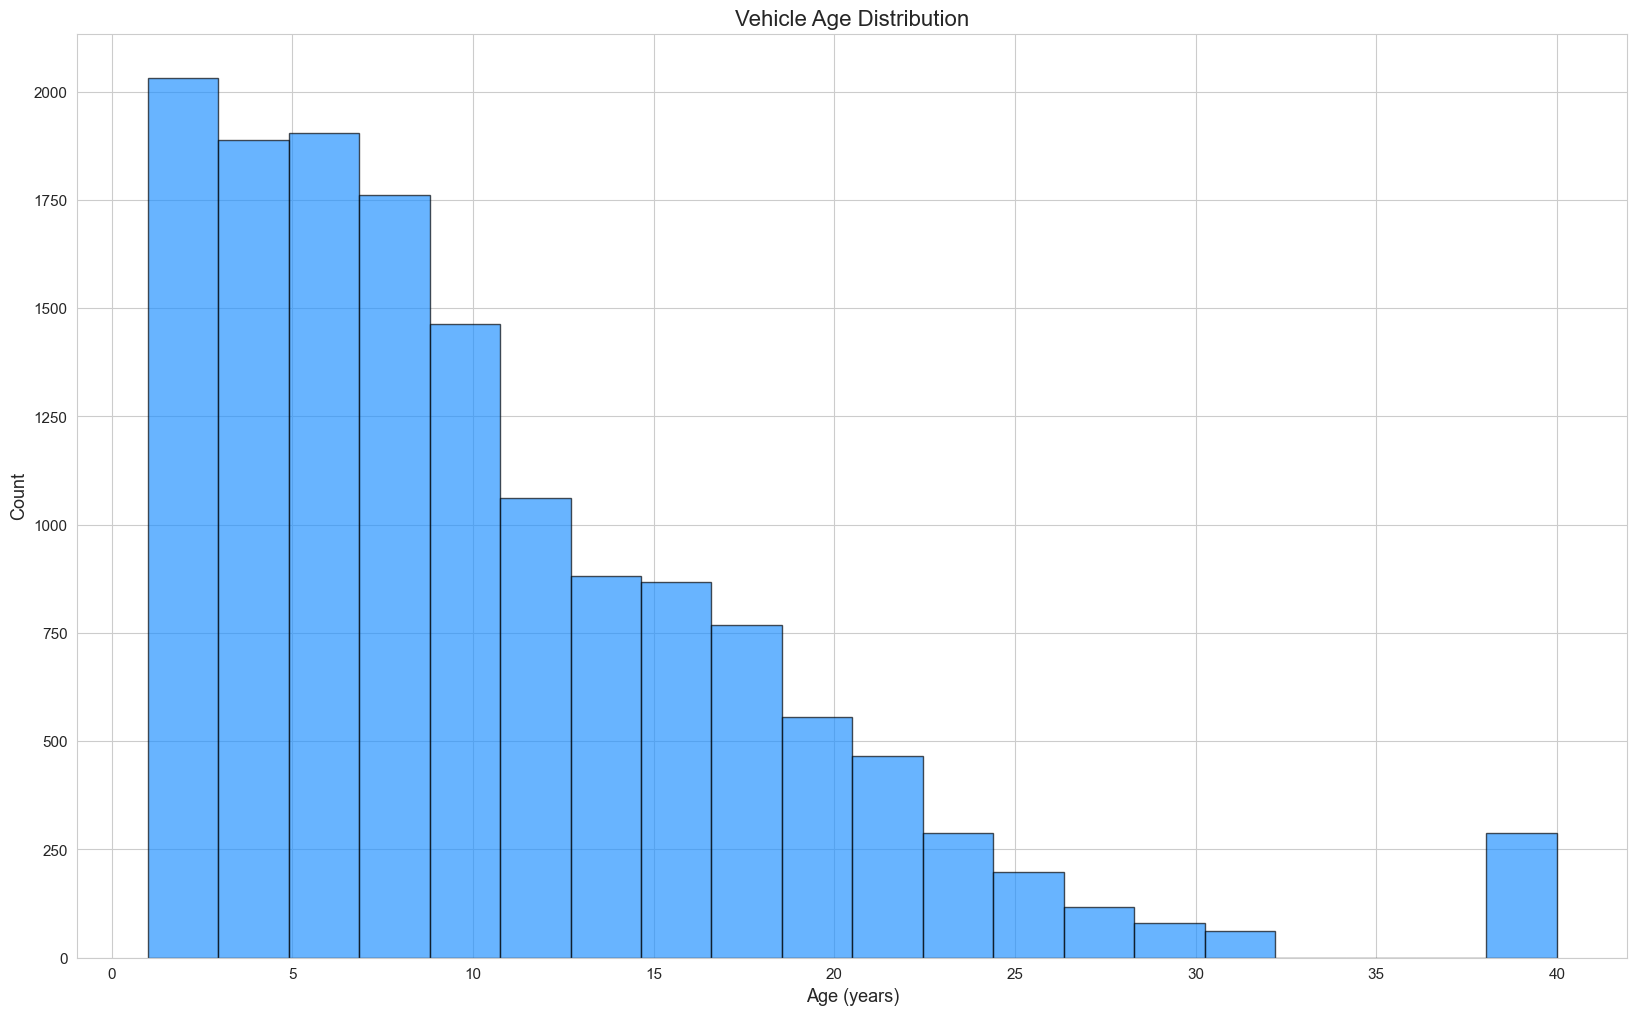

In [10]:
##Let's use matplotlib to create a histogram


##Tell Python you are plotting a figure and how big you want the figure to be
plt.figure(figsize = (20,12))

## Tell Python what type of plot you want. Here, .hist() creates a histogram
plt.hist(nhts_data['vehicle_age'], bins = 20, color = 'dodgerblue', edgecolor = 'black', alpha = .67)

# Then let's label. You'll notice you can change the fontsize of all your labels!
plt.title('Vehicle Age Distribution', fontsize=16)
plt.xlabel('Age (years)', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

In [11]:
# Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    
    
    return acceleration

In [12]:
# Test the IDM function with sample values
# A follower traveling at 20 m/s, with a gap of 25 m, approaching the leader at 2 m/s

# Define parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Test case
test_v = 20        # follower speed
test_s = 25        # gap distance
test_delta_v = 2   # follower is faster than leader by 2 m/s

# Call the function and print the result
test_acc = idm_acceleration(test_v, test_s, test_delta_v, v0, s0, T, a, b, delta)
print(f"IDM Acceleration Calculation Results: {test_acc}")

# Think about: does this value make sense? The follower is approaching the leader, so should it accelerate or decelerate?

IDM Acceleration Calculation Results: -2.9347825286041807


In [13]:
# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM.csv')

# Select a trajectory pair
trajectory_number = 6
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)
# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1 #seconds

print(time_data)

[ 0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4
  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7  2.8
  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1  4.2
  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5  5.6
  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9  7.
  7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3  8.4
  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7  9.8
  9.9 10.  10.1 10.2 10.3 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1 11.2
 11.3 11.4 11.5 11.6 11.7 11.8 11.9 12.  12.1 12.2 12.3 12.4 12.5 12.6
 12.7 12.8 12.9 13.  13.1 13.2 13.3 13.4 13.5 13.6 13.7 13.8 13.9 14.
 14.1 14.2 14.3 14.4 14.5 14.6 14.7 14.8 14.9 15.  15.1 15.2 15.3 15.4
 15.5 15.6 15.7 15.8 15.9 16.  16.1 16.2 16.3 16.4 16.5 16.6 16.7 16.8
 16.9 17.  17.1 17.2 17.3 17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2
 18.3 18.4 18.5 18.6 18.7 18.8 18.9 19.  19.1 19.2 19.3 19.4 19.5 19.6
 19.7 19

In [14]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]        #this makes the starting value [0] same as the follower vehicle speed

In [15]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed [i]

    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]* dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]* dt
print("Simulation complete!")

Simulation complete!


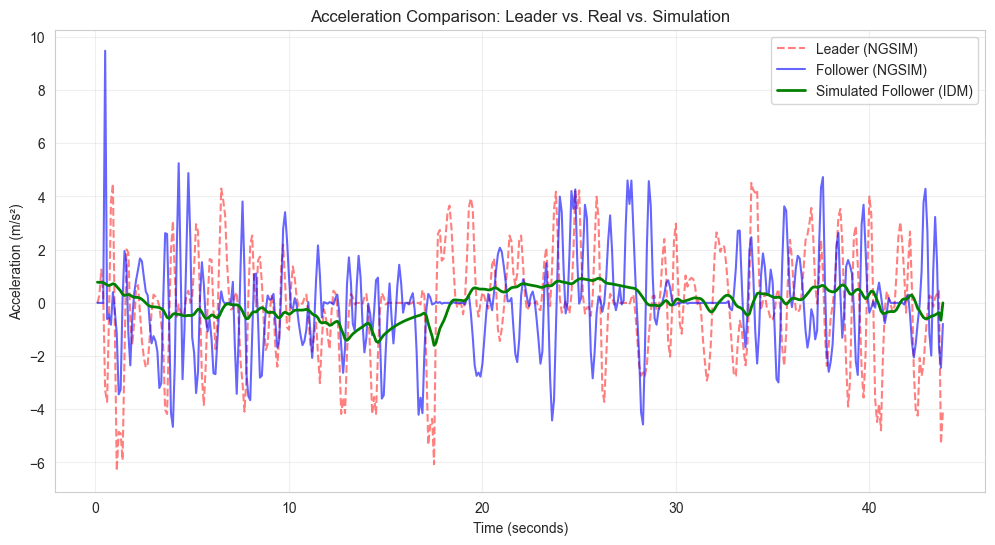

In [16]:
# Plot: Acceleration vs Time — Comparing Leader, Real Follower, and IDM Follower
plt.figure(figsize=(12, 6))

# Calculate Leader Acceleration (dv/dt)
leader_speed_vals = data_subset['leader_speed(m/s)'].values
leader_acc = np.diff(leader_speed_vals, prepend=leader_speed_vals[0]) / dt

# Calculate Real Follower Acceleration (dv/dt)
real_speed_vals = data_subset['follower_speed(m/s)'].values
real_acc = np.diff(real_speed_vals, prepend=real_speed_vals[0]) / dt

# Plot Leader Acceleration
plt.plot(time_data, leader_acc, label='Leader (NGSIM)', color="red", linestyle='--', alpha=0.5)

# Plot Real Follower Acceleration
plt.plot(time_data, real_acc, label='Follower (NGSIM)', color="blue", alpha=0.6)

# Plot Simulated Follower Acceleration (already calculated in Step 3 loop)
plt.plot(time_data, sim_acc, label='Simulated Follower (IDM)', color="green", linewidth=2)

# Formatting the Plot
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Acceleration Comparison: Leader vs. Real vs. Simulation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

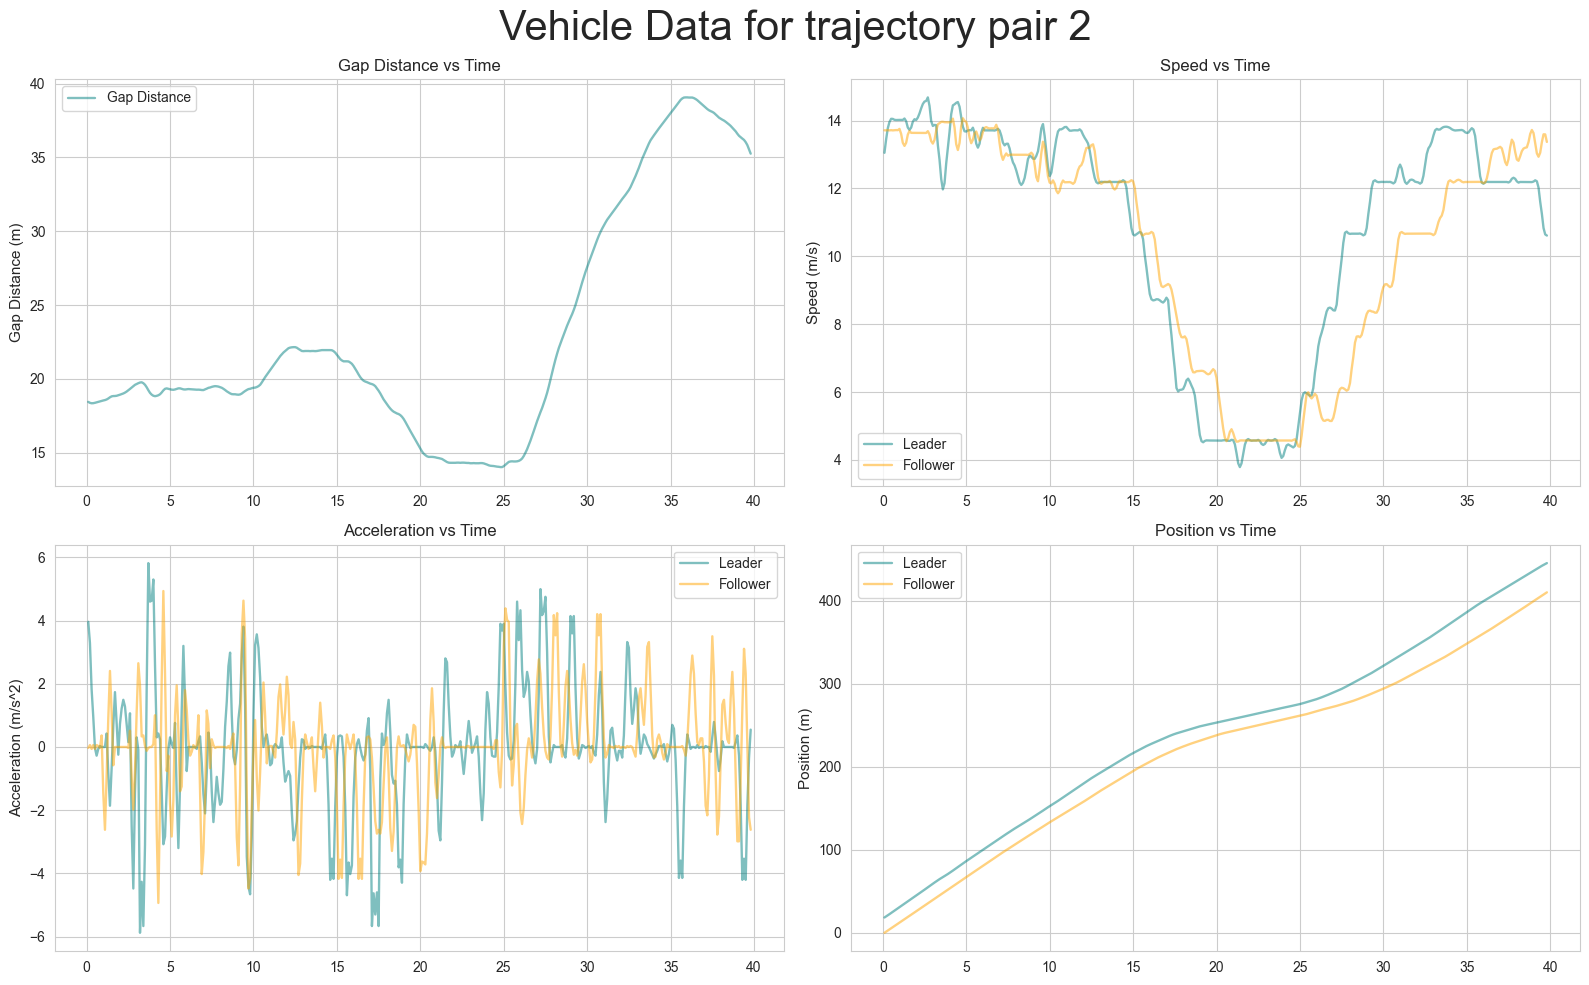

In [17]:
# Create a 2x2 subplot figure showing: trajectory, speed, acceleration, and gap for one vehicle pair

# Step 1: Select a trajectory number and create the subset
trajectory_number = 2
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values

# Step 2: Create the figure with 2 rows and 2 columns
# hint: fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Step 3: Top-left (axes[0,0]): Position vs Time for both leader and follower
axes[1,1].plot(time, data_subset['leader_position(m)'].values, linewidth = 1.7, label = 'Leader', color = 'teal', alpha=0.5)
axes[1,1].plot(time, data_subset['follower_position(m)'].values, linewidth = 1.7, label = 'Follower', color = 'orange', alpha=0.5)
axes[1,1].set_ylabel('Position (m)', fontsize=11)
axes[1,1].set_title('Position vs Time', fontsize=12)
axes[1,1].legend(fontsize = 10)
# Step 4: Top-right (axes[0,1]): Speed vs Time for both leader and follower
axes[0,1].plot(time, data_subset['leader_speed(m/s)'].values, linewidth = 1.7, label = 'Leader', color = 'teal', alpha=0.5)
axes[0,1].plot(time, data_subset['follower_speed(m/s)'].values, linewidth = 1.7, label = 'Follower', color = 'orange', alpha=0.5)
axes[0,1].set_ylabel('Speed (m/s)', fontsize=11)
axes[0,1].set_title('Speed vs Time', fontsize=12)
axes[0,1].legend(fontsize = 10)

# Step 5: Bottom-left (axes[1,0]): Acceleration vs Time for both leader and follower
axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'].values, linewidth = 1.7, label = 'Leader', color = 'teal', alpha=0.5)
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'].values, linewidth = 1.7, label = 'Follower', color = 'orange', alpha=0.5)
axes[1,0].set_ylabel('Acceleration (m/s^2)', fontsize=11)
axes[1,0].set_title('Acceleration vs Time', fontsize=12)
axes[1,0].legend(fontsize = 10)
# Step 6: Bottom-right (axes[1,1]): Gap Distance vs Time
axes[0,0].plot(time, gap_distance, linewidth = 1.7, label = 'Gap Distance', color = 'teal', alpha=0.5)
axes[0,0].set_ylabel('Gap Distance (m)', fontsize=11)
axes[0,0].set_title('Gap Distance vs Time', fontsize=12)
axes[0,0].legend(fontsize = 10)

# Step 7: Add title for the whole figure and adjust layout
fig.suptitle('Vehicle Data for trajectory pair 2', fontsize = 30)
plt.tight_layout()
